Both parts loaded successfully.


C:\Users\ygunj\AppData\Local\Temp\ipykernel_26612\4291893220.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


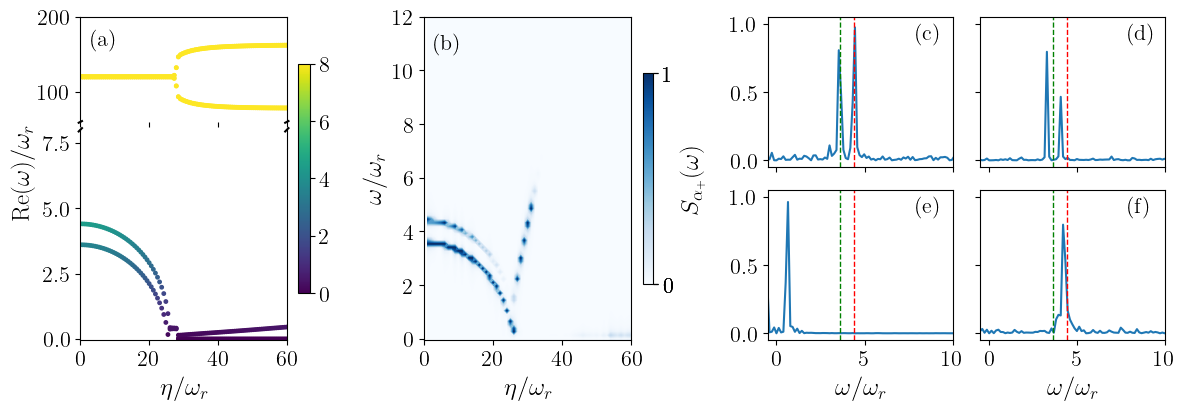

In [11]:
# Load part 1
data1 = np.load( r"Figure_8_data_1.npz")
data2 = np.load( r"Figure_8_data_2.npz")

eigvals_vs_eta = data1['eigvals_vs_eta']
eta_ratios     = data1['eta_ratios']
eta_list       = data1['eta_list']
freq_shift     = data1['freq_shift']
S_map          = data1['S_map']
omega_r        = data1['omega_r']

freq  = data2['freq']

S_ap  = data2['S_ap']
S_bm  = data2['S_bm']

S_ap1 = data2['S_ap1']
S_bm1 = data2['S_bm1']

S_ap2 = data2['S_ap2']
S_bm2 = data2['S_bm2']

S_ap3 = data2['S_ap3']
S_bm3 = data2['S_bm3']

print("Both parts loaded successfully.")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# ============================================================
# PRL STYLE
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    # --- Base font ---
    "font.size": 16,

    # --- Axis labels (x,y) ---
    "axes.labelsize": 18,

    # --- Tick labels ---
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # --- Axes style ---
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
})
# ============================================================
# FIGURE LAYOUT
# ============================================================
fig = plt.figure(figsize=(14,4.2))
gs = GridSpec(1, 3, width_ratios=[0.75,0.75,1.3], wspace=0.4)

# ============================================================
# (a) Broken axis eigenvalues
# ============================================================
gs_a = gs[0,0].subgridspec(2,1, height_ratios=[1,2], hspace=0.05)
ax_a_top = fig.add_subplot(gs_a[0])
ax_a_bot = fig.add_subplot(gs_a[1], sharex=ax_a_top)

norm = Normalize(vmin=0, vmax=8)
cmap = plt.cm.viridis
sm = ScalarMappable(norm=norm, cmap=cmap)

for i in range(eigvals_vs_eta.shape[1]):
    y = np.real(eigvals_vs_eta[:, i]) / omega_r
    c = cmap(norm(y))
    ax_a_top.scatter(eta_ratios, y, c=c, s=6)
    ax_a_bot.scatter(eta_ratios, y, c=c, s=6)

ax_a_bot.set_ylim(-0.05, 8)
ax_a_top.set_ylim(60, 200)
ax_a_bot.set_xlim(eta_ratios.min(), eta_ratios.max())

ax_a_top.spines['bottom'].set_visible(False)
ax_a_bot.spines['top'].set_visible(False)
ax_a_top.tick_params(labelbottom=False)

ax_a_bot.set_xlabel(r'$\eta / \omega_r$')
ax_a_bot.set_ylabel(r'$\mathrm{Re}(\omega)/\omega_r$')
ax_a_bot.yaxis.set_label_coords(-0.22, 0.8)

# ---- Panel label position control ----
ax_a_bot.text(0.05, 1.4, r'(a)', transform=ax_a_bot.transAxes)

# broken marks
d = 0.008
kwargs = dict(transform=ax_a_top.transAxes, color='k', clip_on=False)
ax_a_top.plot((-d,+d),(-d,+d),**kwargs)
ax_a_top.plot((1-d,1+d),(-d,+d),**kwargs)
kwargs.update(transform=ax_a_bot.transAxes)
ax_a_bot.plot((-d,+d),(1-d,1+d),**kwargs)
ax_a_bot.plot((1-d,1+d),(1-d,1+d),**kwargs)

# ---- Clean integer colorbar for (a) ----
cbar_a = fig.colorbar(sm, ax=[ax_a_top, ax_a_bot], fraction=0.05)

# Get min/max from normalization
vmin = norm.vmin
vmax = norm.vmax

# Create 5 evenly spaced integer ticks
ticks_a = np.linspace(vmin, vmax, 5)
ticks_a = np.round(ticks_a).astype(int)

cbar_a.set_ticks(ticks_a)
cbar_a.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# ============================================================
# (b) 2D spectrum
# ============================================================
ax_b = fig.add_subplot(gs[0,1])

cont = ax_b.contourf(eta_list/omega_r,
                     freq_shift,
                     S_map.T,
                     levels=400,
                     cmap='Blues')

ax_b.set_xlim([0,60])
ax_b.set_ylim([-0.05,12])

ax_b.set_xlabel(r'$\eta/\omega_r$')
ax_b.set_ylabel(r'$\omega/\omega_r$')

ax_b.text(0.05, 0.9, r'(b)', transform=ax_b.transAxes)

# ---- Colorbar (b) with fewer integer ticks ----
cbar_b = fig.colorbar(cont, ax=ax_b, fraction=0.046)

# Get min/max of spectrum
vmin = np.nanmin(S_map)
vmax = np.nanmax(S_map)

# Create 5 integer ticks between min and max
ticks = np.linspace(np.floor(vmin), np.ceil(vmax), 5)
ticks = np.round(ticks).astype(int)

cbar_b.set_ticks(ticks)
cbar_b.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

cbar_b.set_label(r"$S_{\alpha_+}(\omega)$")

# ============================================================
# Helper function for spectra
# ============================================================
def spectrum_plot(ax, Sap, Sbm):
    ax.plot(freq/omega_r, Sap, lw=1)
    ax.plot(freq/omega_r, Sbm, lw=1)
    ax.set_xlim([-10,10])
    ax.tick_params(direction='out')
    ax.set_xticks([-10,0,10])

# ============================================================
# (c)-(f) 2×2 matrix
# ============================================================
gs_right = gs[0,2].subgridspec(2,2, hspace=0.15, wspace=0.15)

ax_c = fig.add_subplot(gs_right[0,0])
ax_d = fig.add_subplot(gs_right[0,1])
ax_e = fig.add_subplot(gs_right[1,0])
ax_f = fig.add_subplot(gs_right[1,1])

def spectrum_plot(ax, Sap, Sam, freq, omega_r):

    x = freq / omega_r

    # --- plot blue second (on top) ---
    ax.plot(x, Sap,
            color='C0',
            lw=1.5,
            zorder=2)

    # --- vertical lines ---
    ax.axvline(4.4, color='r', linestyle='--', lw=1)
    ax.axvline(3.61, color='g', linestyle='--', lw=1)

    ax.set_xlim([-0.5, 10])
    ax.tick_params(direction='out')
    ax.set_xticks([0, 5 ,10])
    
spectrum_plot(ax_c, S_ap,  S_bm,  freq, omega_r)
spectrum_plot(ax_d, S_ap1, S_bm1, freq, omega_r)
spectrum_plot(ax_e, S_ap2, S_bm2, freq, omega_r)
spectrum_plot(ax_f, S_ap3, S_bm3, freq, omega_r)

# ---- Remove x ticks + labels of (c) and (d)
ax_c.tick_params(labelbottom=False)
ax_d.tick_params(labelbottom=False)

# ---- Remove y ticks + labels of (d) and (f)
ax_d.tick_params(labelleft=False)
ax_f.tick_params(labelleft=False)

# ---- Bottom row x labels only
ax_e.set_xlabel(r'$\omega/\omega_r$')
ax_f.set_xlabel(r'$\omega/\omega_r$')


# ---- Panel labels with adjustable position
ax_c.text(0.8, 0.85, r'(c)', transform=ax_c.transAxes)
ax_d.text(0.8, 0.85, r'(d)', transform=ax_d.transAxes)
ax_e.text(0.8, 0.85, r'(e)', transform=ax_e.transAxes)
ax_f.text(0.8, 0.85, r'(f)', transform=ax_f.transAxes)

plt.tight_layout()
plt.show()